In [ ]:
import os
import glob
import random
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [7]:
df = pd.read_csv("hasta_etiketler.csv", sep=";")
df["Teshis"] = df["Teshis"].replace({
    "COPD4": "COPD",
    "COPD3": "COPD",
    "COPD2": "COPD",
    "COPD0": "COPD",
})
label_dict = dict(zip(df["ID"], df["Teshis"]))
label_dict["H001"] = "Healthy" 
label_dict

{'H001': 'Healthy',
 'H002': 'COPD',
 'H003': 'COPD',
 'H004': 'COPD',
 'H005': 'COPD',
 'H006': 'COPD',
 'H007': 'COPD',
 'H008': 'COPD',
 'H009': 'COPD',
 'H010': 'COPD',
 'H011': 'COPD',
 'H012': 'COPD',
 'H013': 'COPD',
 'H014': 'COPD',
 'H015': 'COPD',
 'H016': 'COPD',
 'H017': 'COPD1',
 'H018': 'COPD',
 'H019': 'Asthma',
 'H020': 'Asthma',
 'H021': 'COPD',
 'H022': 'COPD',
 'H023': 'COPD',
 'H024': 'COPD',
 'H025': 'COPD',
 'H026': 'COPD',
 'H027': 'Asthma',
 'H028': 'COPD',
 'H029': 'COPD1',
 'H030': 'COPD',
 'H031': 'COPD',
 'H032': 'COPD',
 'H033': 'COPD',
 'H034': 'COPD',
 'H035': 'COPD',
 'H036': 'COPD',
 'H037': 'COPD',
 'H038': 'COPD',
 'H039': 'COPD1',
 'H040': 'COPD',
 'H041': 'COPD',
 'H042': 'COPD',
 'H043': 'COPD1',
 'H044': 'COPD',
 'H045': 'COPD1',
 'H046': 'Asthma',
 'H047': 'Asthma',
 'H048': 'Healthy',
 'H049': 'Healthy',
 'H050': 'COPD',
 'H051': 'Asthma',
 'H052': 'Healthy',
 'H053': 'Healthy',
 'H054': 'Healthy',
 'H055': 'Healthy',
 'H056': 'Healthy',
 'H057'

In [8]:
def extract_mfcc(file_path, n_mfcc=40):
    y, sr = librosa.load(file_path, sr=22050)
    y = librosa.util.normalize(y)

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=sr,
        n_mfcc=n_mfcc,
        hop_length=512,
        n_fft=2048
    )
    return mfcc.T   # (time, n_mfcc)

In [11]:
X = []
y = []

base_path = "./Datalar"

for class_folder in ["Asthma", "COPD4", "Healthy"]:
    folder_path = os.path.join(base_path, class_folder)
    for file in os.listdir(folder_path):
        if file.endswith(".wav"):
            patient_id = file.split("_")[0]   # H003
            label = label_dict.get(patient_id)

            if label is None:
                continue
            
            mfcc = extract_mfcc(os.path.join(folder_path, file))
            X.append(mfcc)
            y.append(label)

In [14]:
max_len = max([i.shape[0] for i in X])

X = pad_sequences(X, maxlen=max_len, padding="post", dtype="float32")

In [18]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
model = models.Sequential([
    layers.Input(shape=(max_len, 40)),
    
    layers.Conv1D(64, 5, activation='relu'),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, 5, activation='relu'),
    layers.MaxPooling1D(2),
    
    layers.LSTM(128, return_sequences=False),
    
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 1288, 64)       │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 644, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 640, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 320, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,987 (757.76 KB)

 Trainable params: 193,987 (757.76 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=16
)


Epoch 1/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.5000 - loss: 1.06 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.4531 - loss: 1.05 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.4549 - loss: 1.03 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.4583 - loss: 1.02 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.4692 - loss: 1.02 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.4830 - loss: 1.01 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.4982 - loss: 1.01 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.5091 - loss: 1.00 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.5182 - loss: 1.00 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.5263 - loss: 1.00 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5348 - loss: 0.99 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5410 - loss: 0.99 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.5454 - loss: 0.99 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - accuracy: 0.5980 - loss: 1.0037 - val_accuracy: 0.4615 - val_loss: 0.9160
Epo

In [22]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.5938 - loss: 0.795 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.6250 - loss: 0.756 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.6562 - loss: 0.7174
Test Accuracy: 0.65625


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/st ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


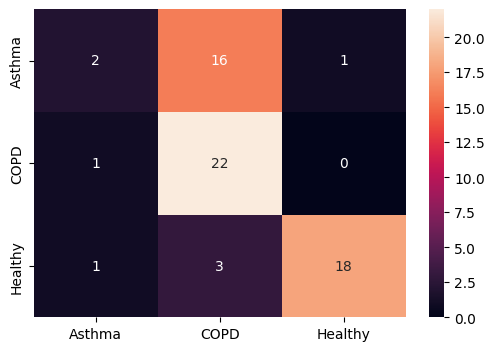

In [23]:
y_pred = model.predict(X_test).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.show()